In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay


In [2]:
diabetes_df = pd.read_csv("diabetes.csv")

In [3]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_df.shape

(768, 9)

In [5]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
diabetes_df.duplicated().sum()

0

In [8]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
diabetes_df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [10]:
diabetes_df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diabetes_df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0, np.nan)

In [11]:
diabetes_df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
diabetes_df.fillna(diabetes_df.median(),inplace=True)

In [13]:
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

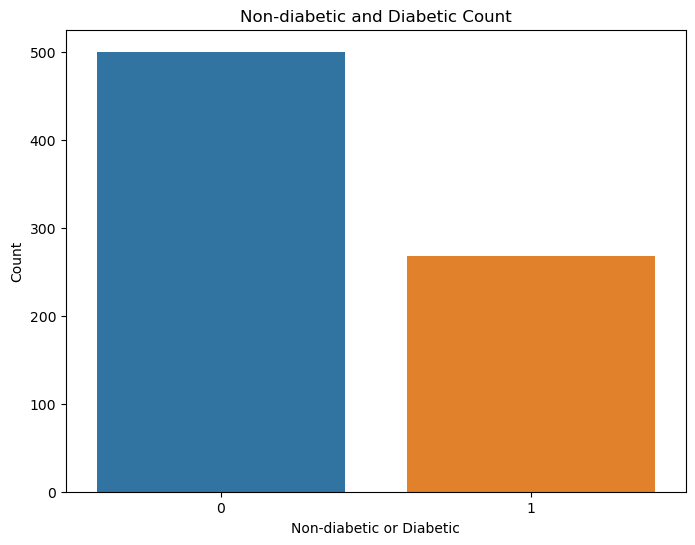

In [14]:
plt.figure(figsize=(8,6))

sns.countplot(data=diabetes_df, x='Outcome')
plt.title("Non-diabetic and Diabetic Count")
plt.xlabel("Non-diabetic or Diabetic")
plt.ylabel("Count")
plt.savefig("Dia_NDia_Cnt.png", dpi=500, bbox_inches='tight')
plt.show()

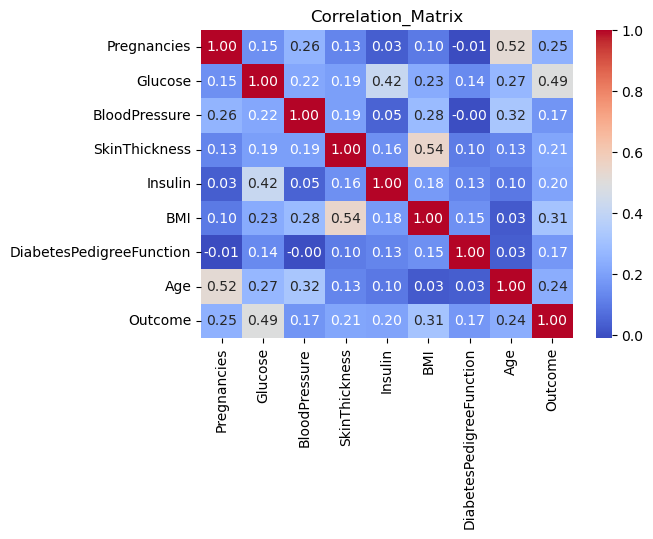

In [15]:
plt.figure(figsize=(6,4))

corr_matrix = diabetes_df.corr()

sns.heatmap(data=corr_matrix, cmap='coolwarm',annot=True,fmt='.2f')
plt.title("Correlation_Matrix")
plt.savefig("Correlation_Matrix.png", dpi=500, bbox_inches='tight')
plt.show()

In [16]:
X= diabetes_df.drop('Outcome', axis=1)
y= diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 1, stratify=y
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
logisticR_mod = LogisticRegression(class_weight='balanced')
logisticR_mod.fit(X_train, y_train)

svm_mod = SVC(class_weight='balanced',probability=True)
svm_mod.fit(X_train, y_train)

RandomForest_mod = RandomForestClassifier(class_weight='balanced') 
RandomForest_mod.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [19]:
LogisticR_mod_y_pred = logisticR_mod.predict(X_test)
svm_mod_y_pred = svm_mod.predict(X_test)
RandomForest_mod_y_pred = RandomForest_mod.predict(X_test)

In [20]:
print("Logistic Regression:\n")
print("Accuracy Score : ",accuracy_score(y_test,LogisticR_mod_y_pred))
print("Confusion Matrix :\n",confusion_matrix(y_test,LogisticR_mod_y_pred))
print("Classification_report :\n",classification_report(y_test,LogisticR_mod_y_pred))

Logistic Regression:

Accuracy Score :  0.7467532467532467
Confusion Matrix :
 [[79 21]
 [18 36]]
Classification_report :
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       100
           1       0.63      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [21]:
print("SVM:\n")
print("Accuracy Score : ",accuracy_score(y_test,svm_mod_y_pred))
print("Confusion Matrix :\n",confusion_matrix(y_test,svm_mod_y_pred))
print("Classification_report :\n",classification_report(y_test,svm_mod_y_pred))

SVM:

Accuracy Score :  0.7467532467532467
Confusion Matrix :
 [[75 25]
 [14 40]]
Classification_report :
               precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154



In [22]:
print("Random Forest :\n")
print("Accuracy Score : ",accuracy_score(y_test,RandomForest_mod_y_pred))
print("Confusion Matrix :\n",confusion_matrix(y_test,RandomForest_mod_y_pred))
print("Classification_report :\n",classification_report(y_test,RandomForest_mod_y_pred))

Random Forest :

Accuracy Score :  0.7272727272727273
Confusion Matrix :
 [[84 16]
 [26 28]]
Classification_report :
               precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.64      0.52      0.57        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



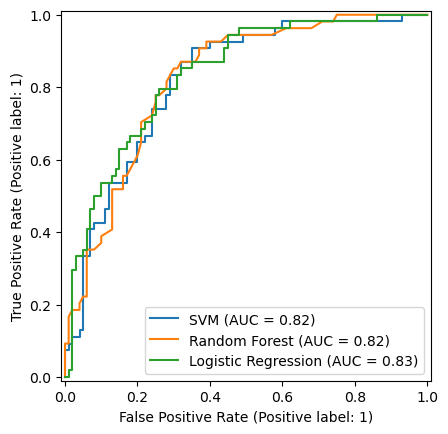

In [23]:
ax = plt.gca()

RocCurveDisplay.from_estimator(svm_mod, X_test, y_test, ax=ax, name="SVM")
RocCurveDisplay.from_estimator(RandomForest_mod, X_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(logisticR_mod, X_test, y_test, ax=ax, name="Logistic Regression")

plt.show()

In [24]:
input_data = (5,166,72,19,175,25.8,0.587,51)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = svm_mod.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.18062364  1.43984721 -0.02547319 -1.14071698  0.45899921 -0.9728019
   0.33590977  1.53337647]]
[1]
The person is diabetic


C:\Users\aditya\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
